# Mathematical Engineering - Financial Engineering, FY 2024-2025
# Risk Management - Exercise 2: Corporate Bond Portfolio and Credit Single Factor Model

In [2]:
# Importing the libraries

import numpy as np
import pandas as pd
import pickle as pk

from scipy.optimize import fsolve   
from scipy.stats import norm

from ex0_utilities import bootstrap, get_discount_factor_by_zero_rates_linear_interp
from date_functions import business_date_offset, year_frac_act_x
from ex2_utilities import (
    defaultable_bond_dirty_price_from_intensity,
    defaultable_bond_dirty_price_from_z_spread,
)

#### Import market data

In [3]:
# =============================================================================
# Bootstrap the discount curve from market data (Assignment 0)
# =============================================================================
dt = pd.read_csv('dt.csv',
                index_col = 'Market',
                usecols = ['Market','TARGET'],
                converters = {'TARGET':pd.to_datetime})

depo_converter = lambda x: float(x)
df_depos = pd.read_csv('depos.csv', 
                   index_col ='Depos',
                   usecols = ['Depos','ASK','BID'], 
                    converters={'Depos':pd.to_datetime,'BID':depo_converter,'ASK':depo_converter})

future_converter = lambda x: float(x)
futures = pd.read_csv('futures.csv',
                      index_col ='Futures',
                      usecols = ['Futures','ASK','BID'],
                      converters = {'Futures':pd.to_datetime, 'Settle':pd.to_datetime, 'Expiry':pd.to_datetime})
expiry = pd.read_csv('expiry.csv',
                     index_col = 'Futures',
                     usecols =['Futures', 'Settle', 'Expiry'], 
                     converters = {'Futures':pd.to_datetime, 'Settle':pd.to_datetime, 'Expiry':pd.to_datetime})
df_futures = futures.join(expiry)

swap_converter = lambda x: float(x)
df_swaps = pd.read_csv('swaps.csv',
                    index_col = 'Swaps',
                    usecols = ['Swaps','BID','ASK'],
                    converters={'Swaps':pd.to_datetime,'BID':swap_converter,'ASK':swap_converter})

today = dt.TARGET['Today']
settlement_date  = dt.TARGET['Settlement']

# Storing the data in a dictionary
market_data = dict()
market_data["reference_date"] = settlement_date
market_data["depo"] = df_depos
market_data["futures"] = df_futures
market_data["swaps"] = df_swaps
pk.dump(market_data, open("market_data.p", "wb"))


# Bootstrap
discount_factors, zero_rates = bootstrap(settlement_date, df_depos, df_futures, df_swaps)

#### Portfolio A

In [4]:
# Parameters
maturity1 = 1  # Maturity in years
maturity2 = 2
notional1 = 1e7
notional2 = 1e7
coupon_rate1 = 0.055
coupon_rate2 = 0.07
coupon_freq1 = 2  # Coupon frequency in payments a years
coupon_freq2 = 2
dirty_price1 = 100.0
dirty_price2 = 103.0

recovery_rate = 0.40

rating = "IG"  # Credit rating

expiry1 = business_date_offset(today, year_offset=maturity1)
expiry2 = business_date_offset(today, year_offset=maturity2)

#### Z-spread

Price of defaultable bond, with coupon rate $c$ as function of the $z$-spread, ignoring the accrual:

$\hat{C}(t,T) = c\sum_{n=1}^N \delta_n\hat{B}(t,t_n)+\hat{B}(t,t_N)$

where 
- $\hat{B}(t,t_n) = B(t,t_n) \exp{ \{-\int_t^{t_n} z(s)ds\} }$

#### Q1: Z-spread calculation, assumed constant

In [5]:
z_spread_1y = fsolve(
    lambda z_spread: defaultable_bond_dirty_price_from_z_spread(
        settlement_date, #FIX: was today,today
        today,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        z_spread[0],
        discount_factors,
        100,
    )
    - dirty_price1,
    x0=0.02,
)[0]

z_spread_2y = fsolve(
    lambda z_spread: defaultable_bond_dirty_price_from_z_spread(
        settlement_date, #FIX: it was today,today
        today,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        z_spread[0],
        discount_factors,
        100,
    )
    - dirty_price2,
    x0=0.02,
)[0]


print(f"Z-spread over {maturity1}y: {z_spread_1y:.6%}")
print(f"Z-spread over {maturity2}y: {z_spread_2y:.6%}")

Z-spread over 1y: 1.472179%
Z-spread over 2y: 1.518743%


#### Intensity

Price of defaultable bond, with coupon rate $c$ and recovery rate $\pi$, ignoring the accrual:

$\bar{C}(t,T) = c\sum_{n=1}^N \delta_n\bar{B}(t,t_n)+\bar{B}(t,t_N) +\pi \sum_{n=1}^N e(t;t_{n-1},t_n)$

where 

- $\bar{B}(t,T) = B(t,T) P(t,T)$ is the price of a defaultable zero coupon bond
- $P(t,T)=\exp{\{-\int_t^T \lambda(s)ds\}}$ is the survival probability up to time $T$, with $\lambda(s)$ intensity
- $e(t;t_{n-1},t_n)=B(t,t_n)(P(t,t_{n-1})-P(t,t_n))$ where $P(t,t_{n-1})-P(t,t_n)$ is the default probability between $t_{n-1}$ and $t_n$

#### Q2: Derive the average intensities for the two bonds and default probabilities

In [6]:
# Intensities average
h_1y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        today,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price1,
    x0=0.02,
)[0]

h_2y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        today,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price2,
    x0=0.02,
)[0]
  
print(f"Average intensity over {maturity1}y: {h_1y:.6%}")
print(f"Average intensity over {maturity2}y: {h_2y:.6%}")

Average intensity over 1y: 2.415665%
Average intensity over 2y: 2.462812%


In [7]:
yf_1y = year_frac_act_x(settlement_date, expiry1, 365)
yf_2y = year_frac_act_x(settlement_date, expiry2, 365)

# Survival probabilities
surv_prob_1y = np.exp(-h_1y * yf_1y)
surv_prob_2y = np.exp(-h_2y * yf_2y)

# Defaul probabilities
default_prob_1y = 1-surv_prob_1y
default_prob_2y = 1-surv_prob_2y 

print(f"{maturity1}y default probability: {default_prob_1y:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y:.6%}")

1y default probability: 2.373800%
2y default probability: 4.787011%


#### Q3: Default probability estimates under the hp. of piecewise constant intensity

In [8]:
# Intensities piecewise
# First year: as before:

h_1y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date, 
        today,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price1,
    x0=0.02,
)[0]

#Second year: we solve the system with lambda2 as the only unknown:
h_1y2y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        today,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        pd.Series(data=[h_1y, intensity[0]], index=[expiry1, expiry2]),
        discount_factors,
        100,
    )
    - dirty_price2,
    x0=0.02,
)[0]

print(f"Piecewise constant intensity over {maturity1}y: {h_1y:.6%}")
print(f"Piecewise constant intensity over {maturity2}y: {h_1y2y:.6%}")


Piecewise constant intensity over 1y: 2.415665%
Piecewise constant intensity over 2y: 2.514095%


Text(0.5, 1.0, 'Intensity')

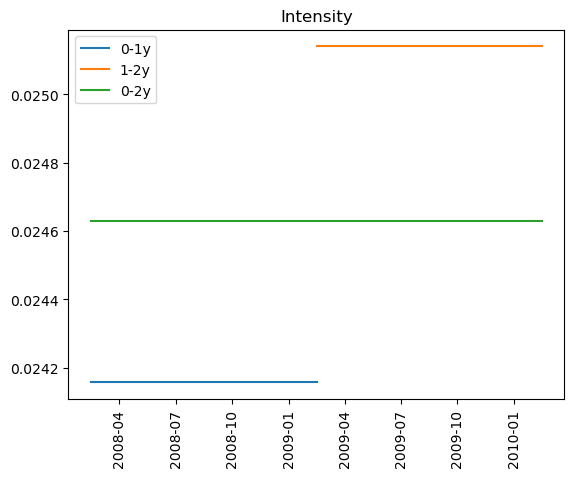

In [9]:
import matplotlib.pyplot as plt

plt.plot([today, expiry1], [h_1y, h_1y])
plt.plot([expiry1, expiry2], [h_1y2y, h_1y2y])
plt.plot([today, expiry2], [h_2y, h_2y])
plt.xticks(rotation=90)
plt.legend([f"0-{maturity1}y", f"{maturity1}-{maturity2}y", f"0-{maturity2}y"])
plt.title("Intensity")

In [10]:
# Survival probabilities
yf_1y = year_frac_act_x(settlement_date, expiry1, 365)
yf_1y2y = year_frac_act_x(expiry1, expiry2, 365)

surv_prob_1y = np.exp(-h_1y * yf_1y)
surv_prob_2y = surv_prob_1y * np.exp(-h_1y2y * yf_1y2y)

# Defaul probabilities
default_prob_1y = 1-surv_prob_1y
default_prob_2y = 1-surv_prob_2y 


print(f"{maturity1}y default probability: {default_prob_1y:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y:.6%}")

1y default probability: 2.373800%
2y default probability: 4.791062%


#### Q4: Estimate the default probabilities under a shock of the mid-term creditworthiness

In [11]:
dirty_price1_shock = dirty_price1
dirty_price2_shock = 97.0

# Choosing piecewise constant intensity because it's a better approximation
# Intensities piecewise

h_1y_shock = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        today,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price1_shock,
    x0=0.02,
)[0]

h_1y2y_shock = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        today,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        pd.Series(data=[h_1y_shock, intensity[0]], index=[expiry1, expiry2]),
        discount_factors,
        100,
    )
    - dirty_price2_shock,
    x0=0.02,
)[0]

surv_prob_1y_shock = np.exp(-h_1y_shock * yf_1y)
surv_prob_2y_shock = surv_prob_1y_shock * np.exp(-h_1y2y_shock * yf_1y2y)

# Defaul probabilities
default_prob_1y_shock = 1-surv_prob_1y_shock
default_prob_2y_shock = 1-surv_prob_2y_shock

print(f"{maturity1}y default probability: {default_prob_1y_shock:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y_shock:.6%}")

1y default probability: 2.373800%
2y default probability: 14.756220%


#### Q5: Real world default probability from the rating transition matrix

In [12]:
# rating transition matrix at 1y

transition_matrix = pd.DataFrame(
    [[0.73, 0.25, 0.02], [0.35, 0.6, 0.05], [0, 0, 1]],
    index=["IG", "HY", "Def"],
    columns=["IG", "HY", "Def"],
)

transition_matrix_2y = transition_matrix.dot(transition_matrix) 

print(
    f"One year real world default probability: {transition_matrix.at[rating, 'Def']:.2%}"
)
print(
    f"Two year real world default probability: {transition_matrix_2y.at[rating, 'Def']:.2%}"
)


real_default_prob_1y = transition_matrix.at[rating, 'Def']
real_default_prob_2y = transition_matrix_2y.at[rating, 'Def']

conditional_real_default_prob_1y2y = (real_default_prob_2y-real_default_prob_1y)/(1-real_default_prob_1y)

conditional_implied_default_prob_1y2y_scenario1 = (default_prob_2y_shock-default_prob_1y_shock)/(1-default_prob_1y_shock)

print(
    f"Real world conditional default probability: {conditional_real_default_prob_1y2y:.2%}"
)
print(
    f"Implied conditional default probability: {conditional_implied_default_prob_1y2y_scenario1:.2%}"
)


One year real world default probability: 2.00%
Two year real world default probability: 4.71%
Real world conditional default probability: 2.77%
Implied conditional default probability: 12.68%


#### Q6: Bond portfolio priced with transition matrix
One year IG zero-coupon bond

$\bar{B}^{IG}(t,t_1)=(1-\pi_{1,3})B(t,t_1) + \pi_{1,3} B(t,t_1/2)\eta$

Two years IG zero-coupon bond

$\bar{B}^{IG}(t,t_2)=\pi_{1,1}B(t,t_1)\bar{B}^{IG}(t_1,t_2) + \pi_{1,2}B(t,t_1)\bar{B}^{HY}(t_1,t_2)+\pi_{1,3}B(t,t_1/2) \eta$

where:
- $\eta$ is the recovery
- $\bar{B}^{IG}(t_1,t_2)$ is the forward zero coupon bond IG
- $\bar{B}^{HY}(t_1,t_2)$ is the forward zero coupon bond HY

In [13]:
# Parameters
issuers_num = 100  # Number of bonds in the portfolio
maturity = 2  # Maturity in years

rating = "IG"  # Credit rating

expiry = business_date_offset(today, year_offset=maturity)

# Same matrix as before
transition_matrix = pd.DataFrame(
    [[0.73, 0.25, 0.02], [0.35, 0.6, 0.05], [0, 0, 1]],
    index=["IG", "HY", "Def"],
    columns=["IG", "HY", "Def"],
)

recovery_rate = 0.4
face_value = 1_000_000   # of each bond
rho = [0.0, 0.25, 0.50]
mc_simulations = 1_000_000

In [14]:
# a) Portfolio MtM assuming all issuers IG

# Get all the relevant discount factors

df_expiry = get_discount_factor_by_zero_rates_linear_interp(settlement_date,expiry,discount_factors.index,discount_factors.values)

# We consider the default at the midpoint

df_1y_def = get_discount_factor_by_zero_rates_linear_interp(
    settlement_date,
    business_date_offset(settlement_date, month_offset=6),  # "average" time of default, if default is between today and 1y
    discount_factors.index,
    discount_factors.values,
)

df_2y_def = get_discount_factor_by_zero_rates_linear_interp(
    settlement_date,
    business_date_offset(settlement_date, month_offset=18),  # "average" time of default, if default is between 1y and 2y
    discount_factors.index,
    discount_factors.values,
)


survival_prob_1y = 1 - real_default_prob_1y
survival_prob_2y = 1 - real_default_prob_2y 
default_prob_between_1y_2y = real_default_prob_2y - real_default_prob_1y

bond_mtm = (1-real_default_prob_2y)*df_expiry + recovery_rate*(df_1y_def*real_default_prob_1y+df_2y_def * default_prob_between_1y_2y)

ptf_mtm = issuers_num * face_value * bond_mtm
print(f"Portfolio MtM: €{ptf_mtm:,.2f}")

Portfolio MtM: €90,175,660.67


In [15]:
# b) Evaluate the present value in 1 year time under various scenarios

ref_date = business_date_offset(settlement_date, year_offset=1) 

df_expiry = get_discount_factor_by_zero_rates_linear_interp(settlement_date,expiry,discount_factors.index,discount_factors.values)
df_ref_date = get_discount_factor_by_zero_rates_linear_interp(settlement_date,ref_date,discount_factors.index,discount_factors.values)


fwd_df = df_expiry/df_ref_date          # forward discount factor B(reference_date,expiry)
fwd_df_1y_def = df_2y_def/df_ref_date   # forward discount factor B(reference_date,"avg" default date)

survival_prob_ig_1y = 1-transition_matrix.at["IG", 'Def']
survival_prob_hy_1y = 1-transition_matrix.at["HY","Def"]

#forward price depending on which state they are at 1y:
fwd_price_ig = fwd_df * survival_prob_ig_1y + recovery_rate * (1 - survival_prob_ig_1y) * fwd_df_1y_def
fwd_price_hy = fwd_df * survival_prob_hy_1y + recovery_rate * (1 - survival_prob_hy_1y) * fwd_df_1y_def 


fwd_price = (
    fwd_price_ig * transition_matrix.at["IG", "IG"]
    + fwd_price_hy * transition_matrix.at["IG", "HY"]
    + recovery_rate * transition_matrix.at["IG", "Def"] * df_1y_def/df_ref_date 
)

print(f"Forward price IG: {fwd_price_ig:.6f}")
print(f"Forward price HY: {fwd_price_hy:.6f}")
print(f"Expected forward price: {fwd_price:.6f}")
print(f"PV at t0: {fwd_price * df_ref_date:.6f}")

Forward price IG: 0.953216
Forward price HY: 0.936074
Expected forward price: 0.938015
PV at t0: 0.901757


In [16]:
# c) Monte Carlo simulation
# Barriers and PnL for a single IG issuer

barrier_default = norm.ppf(transition_matrix.at["IG", "Def"])
barrier_downgrade = norm.ppf(transition_matrix.at["IG", "Def"] + transition_matrix.at["IG", "HY"]) 

barrier_upgrade = np.inf  # IG name can't be upgraded

loss_given_default = recovery_rate * df_1y_def / df_ref_date - fwd_price
loss_given_downgrade = fwd_price_hy - fwd_price
loss_status_quo = fwd_price_ig - fwd_price
loss_upgrade = 0     # upgrade from ig is not possible

In [17]:
# 3 correlation scenarios
# to have the same result at each run, fix the seed
np.random.seed(45)
y = np.random.normal(size=(mc_simulations, 1))
eps = np.random.normal(size=(mc_simulations, issuers_num))

v = []
for correlation in rho:
     v_1 = correlation* y + np.sqrt(1 - correlation**2) * eps
     v.append(v_1)   


In [18]:
# count of defaults, downgrades, upgrades in each simulation...

defaults = [(v[i] < barrier_default).sum(axis=1) for i in range(len(rho))]
downgrades = [((v[i] >= barrier_default) & (v[i] < barrier_downgrade)).sum(axis=1) for i in range(len(rho))]
status_quo = [issuers_num - defaults[i] - downgrades[i] for i in range(len(rho))]


In [19]:
for i, correlation in enumerate(rho):
    print(f"\nCorrelation: {correlation}")
    print(f"Average defaults: {defaults[i].mean():.4f}")
    print(f"Average downgrades: {downgrades[i].mean():.4f}")
    # Marginal check
    print(f"P(default): {defaults[i].mean() / issuers_num:.6f}")
    print(f"P(downgrade): {downgrades[i].mean() / issuers_num:.6f}")
    print(f"P(status quo): {status_quo[i].mean() / issuers_num:.6f}")





Correlation: 0.0
Average defaults: 2.0006
Average downgrades: 25.0048
P(default): 0.020006
P(downgrade): 0.250048
P(status quo): 0.729946

Correlation: 0.25
Average defaults: 2.0017
Average downgrades: 25.0068
P(default): 0.020017
P(downgrade): 0.250068
P(status quo): 0.729915

Correlation: 0.5
Average defaults: 2.0015
Average downgrades: 25.0092
P(default): 0.020015
P(downgrade): 0.250092
P(status quo): 0.729893


In [32]:
# Evaluating the one-year 99% VaR by taking into account defaults only/defaults and rating changes:

for i, correlation in enumerate(rho):
    print(f"\nCorrelation: {correlation}")
    
    # Defaults only
    scenario_def = defaults[i] * loss_given_default
    VaR_def = -np.quantile(scenario_def, 0.01) * face_value
    
    # Defaults + migrations
    scenario_all = defaults[i]*loss_given_default + downgrades[i] * loss_given_downgrade + status_quo[i]*loss_status_quo
    VaR_all = -np.quantile(scenario_all, 0.01) * face_value
    
    expected_loss_def = - scenario_def.mean() * face_value
    expected_loss_all = - scenario_all.mean() * face_value
    
    print(f"Expected loss defaults only: {expected_loss_def:,.2f}€")
    print(f"Expected loss all migrations : {expected_loss_all:,.2f}€")
    print(f"VaR 99% (defaults only): {VaR_def:,.2f}€")
    print(f"VaR 99% (defaults + migrations): {VaR_all:,.2f}€")


Correlation: 0.0
Expected loss defaults only: 1,061,508.33€
Expected loss all migrations : 427.84€
VaR 99% (defaults only): 3,183,517.41€
VaR 99% (defaults + migrations): 2,166,007.95€

Correlation: 0.25
Expected loss defaults only: 1,062,078.18€
Expected loss all migrations : 1,047.59€
VaR 99% (defaults only): 4,244,689.88€
VaR 99% (defaults + migrations): 3,583,292.28€

Correlation: 0.5
Expected loss defaults only: 1,061,987.45€
Expected loss all migrations : 995.42€
VaR 99% (defaults only): 8,489,379.76€
VaR 99% (defaults + migrations): 8,258,159.83€


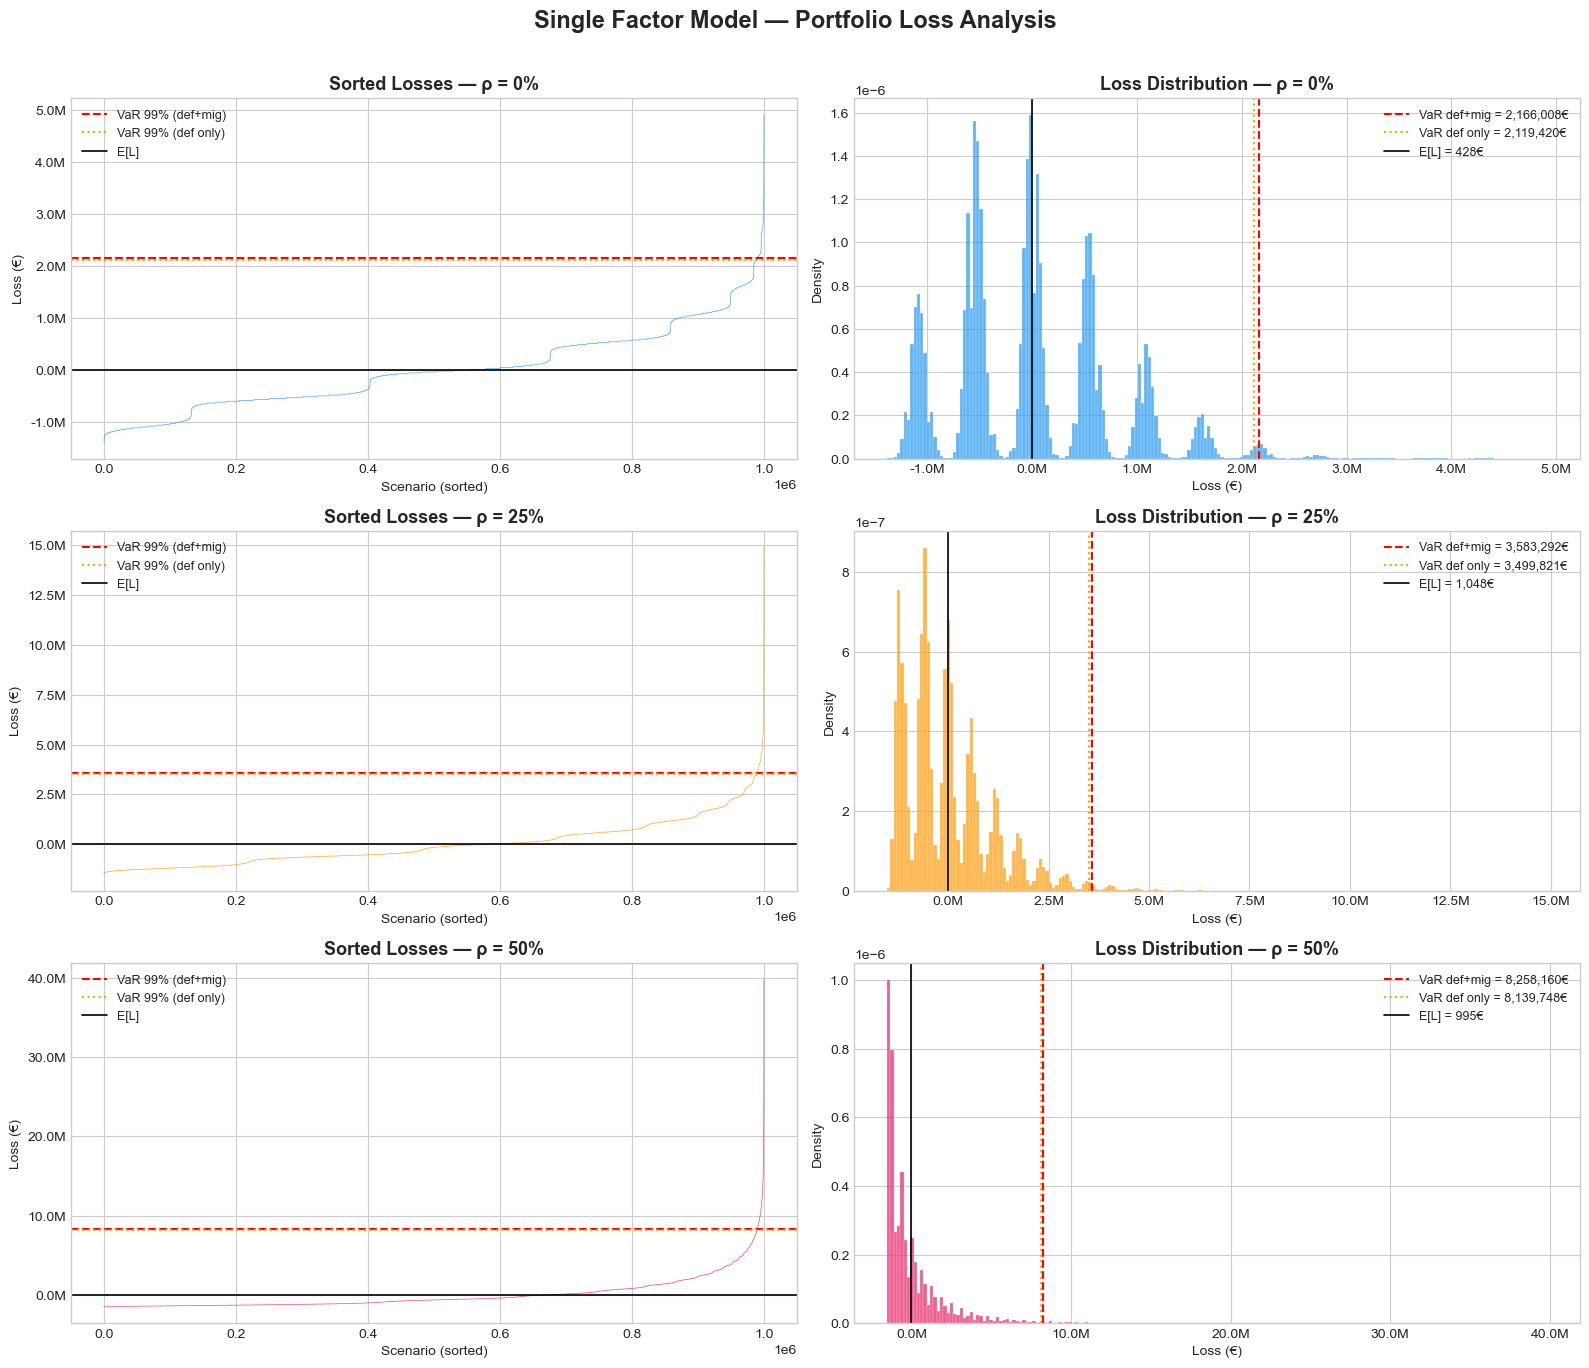

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#2196F3', '#FF9800', '#E91E63']

fig, axes = plt.subplots(len(rho), 2, figsize=(16, 4.5 * len(rho)))

for i, correlation in enumerate(rho):
    scenario_def = defaults[i] * loss_given_default + status_quo[i] * loss_status_quo
    scenario_all = scenario_def + downgrades[i] * loss_given_downgrade
    
    losses = -scenario_all * face_value
    var_def = -np.quantile(scenario_def, 0.01) * face_value
    var_all = -np.quantile(scenario_all, 0.01) * face_value
    el = losses.mean()

    # Sorted losses
    axes[i, 0].plot(np.sort(losses), color=colors[i], linewidth=0.5, alpha=0.8)
    axes[i, 0].axhline(var_all, color='red', linestyle='--', linewidth=1.5, label=f'VaR 99% (def+mig)')
    axes[i, 0].axhline(var_def, color='orange', linestyle=':', linewidth=1.5, label=f'VaR 99% (def only)')
    axes[i, 0].axhline(el, color='black', linestyle='-', linewidth=1.2, label=f'E[L]')
    axes[i, 0].set_title(f'Sorted Losses — ρ = {int(correlation*100)}%', fontsize=13, fontweight='bold')
    axes[i, 0].set_xlabel('Scenario (sorted)', fontsize=10)
    axes[i, 0].set_ylabel('Loss (€)', fontsize=10)
    axes[i, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    axes[i, 0].legend(fontsize=9, loc='upper left')

    # Histogram
    axes[i, 1].hist(losses, bins=200, density=True, color=colors[i], alpha=0.7, edgecolor='white', linewidth=0.2)
    axes[i, 1].axvline(var_all, color='red', linestyle='--', linewidth=1.5, label=f'VaR def+mig = {var_all:,.0f}€')
    axes[i, 1].axvline(var_def, color='orange', linestyle=':', linewidth=1.5, label=f'VaR def only = {var_def:,.0f}€')
    axes[i, 1].axvline(el, color='black', linestyle='-', linewidth=1.2, label=f'E[L] = {el:,.0f}€')
    axes[i, 1].set_title(f'Loss Distribution — ρ = {int(correlation*100)}%', fontsize=13, fontweight='bold')
    axes[i, 1].set_xlabel('Loss (€)', fontsize=10)
    axes[i, 1].set_ylabel('Density', fontsize=10)
    axes[i, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    axes[i, 1].legend(fontsize=9, loc='upper right')

fig.suptitle('Single Factor Model — Portfolio Loss Analysis', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('loss_distribution.png', dpi=300, bbox_inches='tight')
plt.show()